# §1 Individual (unfiltered) (v12)

Per-combo metrics and per-combo equity/drawdown curves on the
20% OOS test partition with no ML#2 filter. Two sizing policies
compared: `fixed_dollars_500` and `pct5_compound`.

In [1]:
import sys
from pathlib import Path
import numpy as np
import pandas as pd

REPO = Path.cwd().resolve()
while not (REPO / 'src').exists() and REPO.parent != REPO:
    REPO = REPO.parent
sys.path.insert(0, str(REPO))

from scripts.evaluation._top_perf_common import (
    STARTING_EQUITY, RISK_FRAC, POLICIES,
    apply_sizing, metrics_from_pnl, monte_carlo,
    load_setup,
    plot_indiv_equity, plot_indiv_dd,
    plot_combined_equity, plot_combined_dd,
    plot_ml2_indiv_equity, plot_ml2_indiv_dd,
    plot_ml2_combined_equity, plot_ml2_combined_dd,
    plot_mc_sims, plot_mc_pnl, plot_mc_sharpe, plot_mc_dd,
)

_ctx = load_setup(cost_per_contract_rt=0.0, top_strategies_path=REPO / 'evaluation' / 'top_strategies_v12.json')
bars            = _ctx['bars']
YEARS_SPAN      = _ctx['years_span']
strategies      = _ctx['strategies']
results_raw     = _ctx['results_raw']
combined_raw    = _ctx['combined_raw']
combos_ml2      = _ctx['combos_ml2']
s4_pnl_by_combo = _ctx['s4_pnl_by_combo']
ml2_portfolio   = _ctx['ml2_portfolio']


Top-K source: top_strategies_v12.json


Test partition: 514,563 bars  2024-10-22 05:08:00 -> 2026-04-08 20:20:00
Years span: 1.461  (used to annualize Sharpe)
Loaded 10 strategies.
results_raw cache stale; rebuilding.
Running unfiltered composed_strategy_runner for each combo...


  v11_2646...


  v11_391...


  v11_28651...


...

    ERROR: [Errno 2] No such file or directory: '/root/intra/data/ml/mfe/ml_dataset_v11_mfe.parquet'
  v11_12101...


    ERROR: [Errno 2] No such file or directory: '/root/intra/data/ml/mfe/ml_dataset_v11_mfe.parquet'
  v11_27291...


    ERROR: [Errno 2] No such file or directory: '/root/intra/data/ml/mfe/ml_dataset_v11_mfe.parquet'
  v11_3547...


    ERROR: [Errno 2] No such file or directory: '/root/intra/data/ml/mfe/ml_dataset_v11_mfe.parquet'
  v11_25420...


    ERROR: [Errno 2] No such file or directory: '/root/intra/data/ml/mfe/ml_dataset_v11_mfe.parquet'
Wrote cache -> _ml2_cache.pkl
ML2 portfolio trade counts: {'fixed_dollars_500': 0, 'pct5_compound': 0}


In [2]:
rows = []
for r in results_raw:
    if r['trades'].empty:
        for policy in POLICIES:
            rows.append({'combo_id': r['combo_id'], 'policy': policy,
                         **metrics_from_pnl(np.array([]), YEARS_SPAN, policy=policy)})
        continue
    t = r['trades'].sort_values('date', kind='mergesort')
    pnl_base = t['actual_pnl'].to_numpy(dtype=float)
    risk_base = t['dollar_risk'].to_numpy(dtype=float)
    r_mult = np.where(risk_base > 0, pnl_base / risk_base, 0.0)
    for policy in POLICIES:
        pnl = apply_sizing(pnl_base, risk_base, policy)
        rows.append({'combo_id': r['combo_id'], 'policy': policy,
                     **metrics_from_pnl(pnl, YEARS_SPAN, policy=policy, r=r_mult)})
perf1 = pd.DataFrame(rows)
perf1

,combo_id,policy,n_trades,trades_per_year,win_rate,total_pnl_dollars,total_return_pct,sharpe_ratio,max_drawdown_pct,max_drawdown_dollars
0,v11_2646,fixed_dollars_500,294,201.2,0.1667,-13728.96,-27.46,-1.2725,37.27,19084.91
1,v11_2646,pct5_compound,294,201.2,0.1667,-45068.80,-90.14,-1.7793,93.01,49981.02
2,v11_391,fixed_dollars_500,178,121.8,0.2809,1941.24,3.88,0.1850,19.32,10781.50
3,v11_391,pct5_compound,178,121.8,0.2809,-14510.52,-29.02,-0.2632,78.46,69868.36
4,v11_28651,fixed_dollars_500,1155,790.5,0.3108,51687.11,103.37,1.4590,20.88,17189.95
5,v11_28651,pct5_compound,1155,790.5,0.3108,98814.61,197.63,0.3134,96.85,585847.30
6,v11_17782,fixed_dollars_500,401,274.5,0.3167,13377.70,26.76,0.7877,16.65,11583.26
7,v11_17782,pct5_compound,401,274.5,0.3167,18117.39,36.23,0.1668,83.83,210921.93
8,v11_263,fixed_dollars_500,482,329.9,0.3444,-15576.70,-31.15,-0.9964,41.49,22657.72
9,v11_263,pct5_compound,482,329.9,0.3444,-46548.65,-93.10,-1.5944,95.99,67022.61


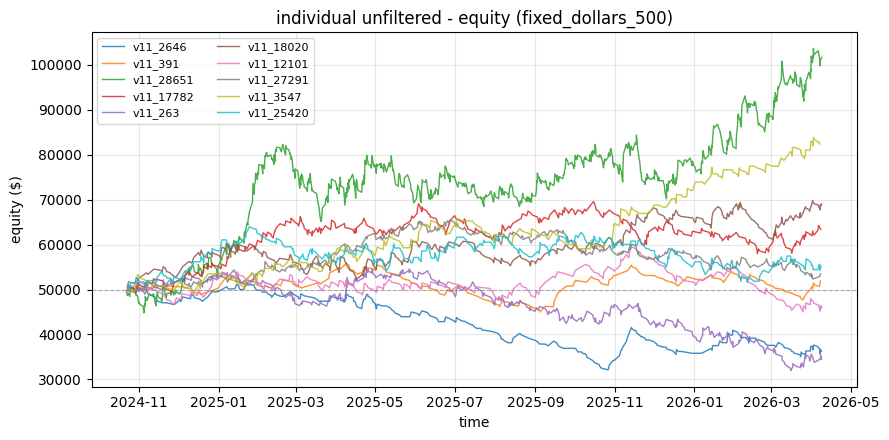

In [3]:
plot_indiv_equity(results_raw, 'fixed_dollars_500')

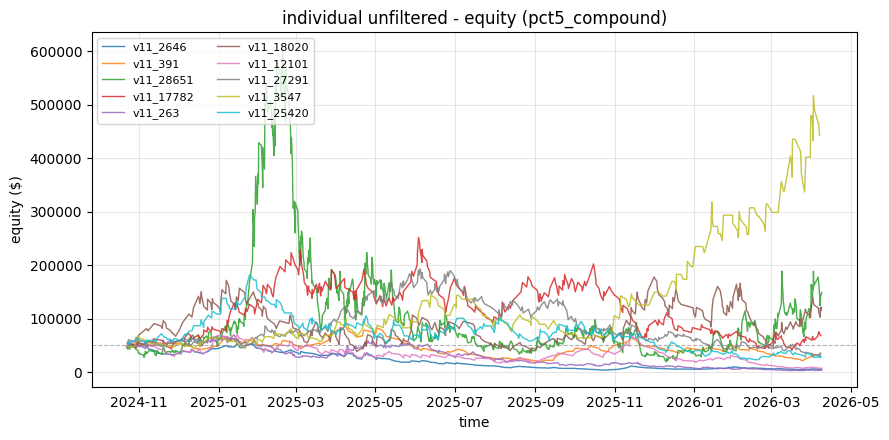

In [4]:
plot_indiv_equity(results_raw, 'pct5_compound')

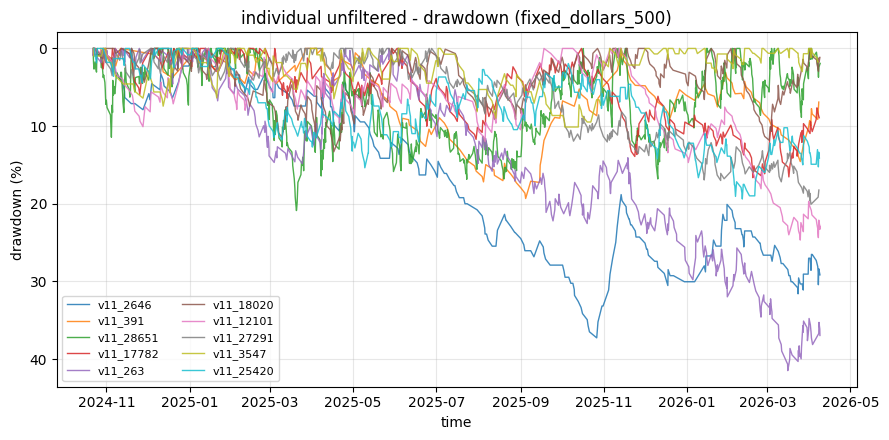

In [5]:
plot_indiv_dd(results_raw, 'fixed_dollars_500')

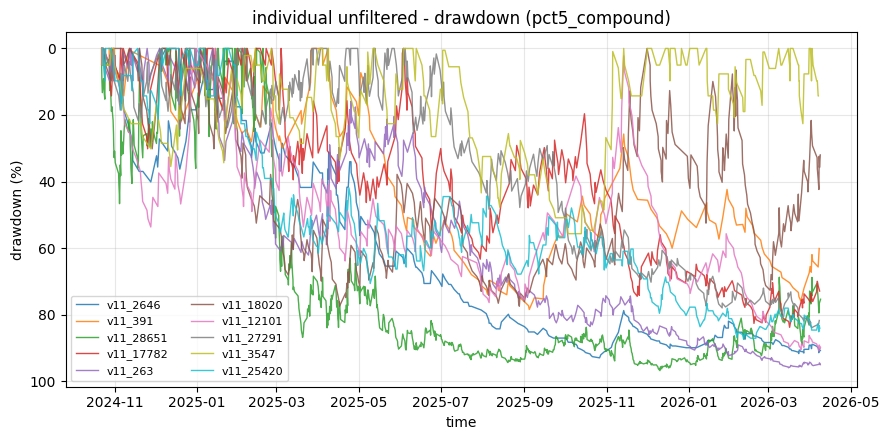

In [6]:
plot_indiv_dd(results_raw, 'pct5_compound')